<a href="https://colab.research.google.com/github/jieunshinda/compensation-benchmarking-tool/blob/main/MM_Market_Analysis_Jieun_Shin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
from collections import defaultdict

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

print("✅ Setup complete")

✅ Setup complete


In [4]:
# Google Drive Mount ─────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PATH = '/content/drive/MyDrive/MM_DA/'
print("✅ Drive mounted:", PATH)

Mounted at /content/drive
✅ Drive mounted: /content/drive/MyDrive/MM_DA/


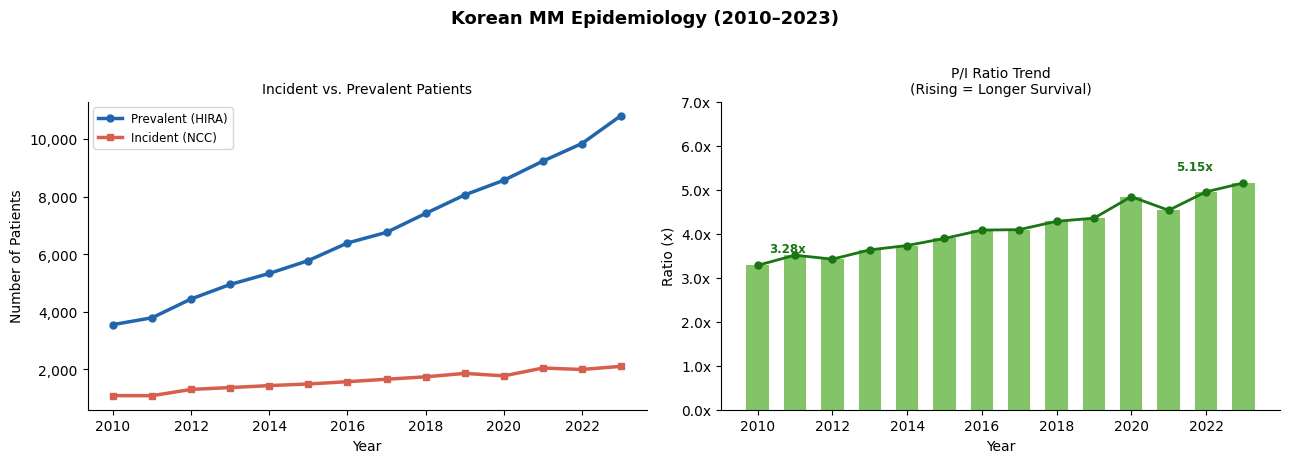

In [5]:
# Data Loading & Merge ───────────────────────────────────────────
# Data sources:
#   - HIRA (건강보험심사평가원): Prevalent MM patients (C900), 2010–2024
#     * Prevalent = patients who received treatment in a given year
#     * Source: 보건의료빅데이터개방시스템 > 질병세분류통계 > C900
#   - NCC (국립암센터): Incident MM patients (C90), 1999–2023
#     * Incident = newly diagnosed patients in a given year
#     * Source: 국가암정보센터 > 암등록통계 > 암종별 발생자수
# ───────────────────────────────────────────────────────────────────────────


# [1] HIRA: Prevalent Patients ───────────────────────────────────────────
hira_raw = pd.read_csv(
    PATH + 'HIRA_MM_Prevalent_Clean_2010_2024.csv',
    encoding='utf-8-sig',
    header=None
)

years    = hira_raw.iloc[2, 2:].tolist()   # row 2: year labels (2010–2024)
patients = hira_raw.iloc[3, 2:].tolist()   # row 3: total patient counts

df_prevalent = pd.DataFrame({
    'year'               : [int(y) for y in years],
    'prevalent_patients' : [int(str(p).replace(',', '')) for p in patients]
})

# Split into main analysis window and out-of-sample validation year
df_prevalent_main = df_prevalent[df_prevalent['year'] <= 2023].reset_index(drop=True)
df_prevalent_val  = df_prevalent[df_prevalent['year'] == 2024].reset_index(drop=True)


# [2] NCC: Incident Patients ─────────────────────────────────────────────
# Filter conditions:
#   - 국제질병분류 == '22. C90': Multiple Myeloma
#   - 성별 == '남녀전체' : Both sexes combined
#   - 연령군 == '연령전체' : All age groups combined
#   - year range filter : Exclude the aggregated row '1999-2023'
ncc_raw = pd.read_csv(
    PATH + 'NCC_MM_Incidence_1999_2023.csv',
    encoding='utf-8-sig'
)

df_incidence = ncc_raw[
    (ncc_raw['국제질병분류'] == '22. C90') &
    (ncc_raw['성별']         == '남녀전체') &
    (ncc_raw['연령군']       == '연령전체') &
    (~ncc_raw['발생연도'].astype(str).str.contains('-'))   # exclude '1999-2023' summary row
].copy()

df_incidence['year'] = df_incidence['발생연도'].astype(int)
df_incidence = (
    df_incidence[['year', '발생자수']]
    .rename(columns={'발생자수': 'incident_patients'})
    .sort_values('year')
    .reset_index(drop=True)
)


# [3] Merge: Inner Join on year (2010–2023) ──────────────────────────────
# inner join automatically retains only overlapping years (2010–2023)
# Result columns: year | incident_patients | prevalent_patients | prevalence_incidence_ratio
df = pd.merge(df_incidence, df_prevalent_main, on='year', how='inner')

# Sanity check: prevalence / incidence ratio
# Global reference (SEER, all living patients): 5-7x
# Korea HIRA expected: lower (~3-5x) — HIRA counts actively treated patients only, excluding patients in long-term remission
df['prevalence_incidence_ratio'] = (
    df['prevalent_patients'] / df['incident_patients']
).round(2)


# [4] Visualization ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Korean MM Epidemiology (2010–2023)',
             fontsize=13, fontweight='bold', y=1.02)

# ── Panel 1: Absolute Patient Counts ───────────────────────────────────────
ax1 = axes[0]
ax1.plot(df['year'], df['prevalent_patients'],
         color='#2166AC', linewidth=2.5, marker='o', markersize=5,
         label='Prevalent (HIRA)')
ax1.plot(df['year'], df['incident_patients'],
         color='#D6604D', linewidth=2.5, marker='s', markersize=5,
         label='Incident (NCC)')
ax1.set_title('Incident vs. Prevalent Patients', fontsize=10)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Patients')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_xticks(range(2010, 2024, 2))
ax1.legend(fontsize=8.5)

# ── Panel 2: P/I Ratio Trend ───────────────────────────────────────────────
ax2 = axes[1]
ax2.bar(df['year'], df['prevalence_incidence_ratio'],
        color='#4DAC26', alpha=0.7, width=0.6)
ax2.plot(df['year'], df['prevalence_incidence_ratio'],
         color='#1A7514', linewidth=2, marker='o', markersize=5)
ax2.set_title('P/I Ratio Trend\n(Rising = Longer Survival)', fontsize=10)
ax2.set_xlabel('Year')
ax2.set_ylabel('Ratio (x)')
ax2.set_ylim(0, 7)
ax2.set_xticks(range(2010, 2024, 2))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax2.annotate(f"{df['prevalence_incidence_ratio'].iloc[0]:.2f}x",
             xy=(2010, df['prevalence_incidence_ratio'].iloc[0]),
             xytext=(2010.3, df['prevalence_incidence_ratio'].iloc[0] + 0.3),
             fontsize=8.5, color='#1A7514', fontweight='bold')
ax2.annotate(f"{df['prevalence_incidence_ratio'].iloc[-1]:.2f}x",
             xy=(2023, df['prevalence_incidence_ratio'].iloc[-1]),
             xytext=(2021.2, df['prevalence_incidence_ratio'].iloc[-1] + 0.3),
             fontsize=8.5, color='#1A7514', fontweight='bold')

plt.tight_layout()
plt.savefig(PATH + 'MM_Epidemiology_Validation.png', dpi=150, bbox_inches='tight')
plt.show()

CAGR Summary
  Incidence  CAGR 2010–2023 : 5.2%   (forecast basis)
  Prevalence CAGR 2010–2023 : 8.9%
  Prevalence CAGR 2019–2024 : 6.9%   (forecast basis)

2024 Prevalence Validation
  OOS CAGR   : 7.6%  (2019–2023)
  Projected  :  11,641
  Actual     :  11,251
  Error      : +3.5%  → ✓ Acceptable


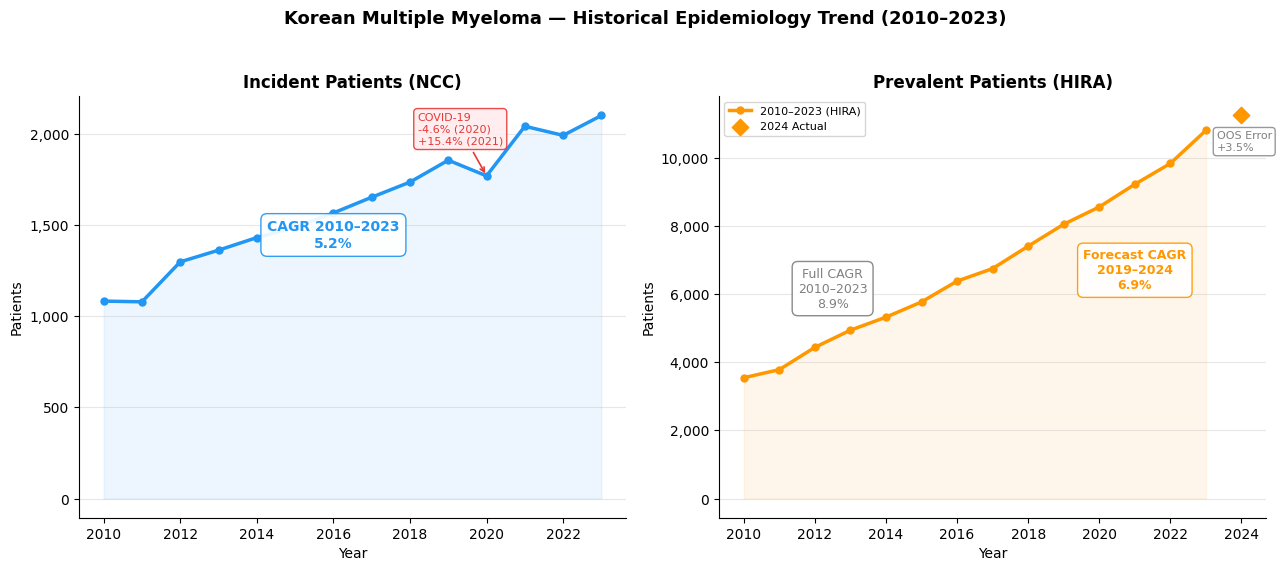

✓ Saved: fig_epidemiology_trend.png


In [6]:
# ── Historical Trend Analysis (2010–2023) ────────────────────────────

# ── Key Data Points ───────────────────────────────────────────────────────────
inc_2010  = df[df['year'] == 2010]['incident_patients'].values[0]
inc_2023  = df[df['year'] == 2023]['incident_patients'].values[0]
inc_2020  = df[df['year'] == 2020]['incident_patients'].values[0]
inc_2019  = df[df['year'] == 2019]['incident_patients'].values[0]
inc_2021  = df[df['year'] == 2021]['incident_patients'].values[0]

prev_2010 = df[df['year'] == 2010]['prevalent_patients'].values[0]
prev_2019 = df[df['year'] == 2019]['prevalent_patients'].values[0]
prev_2023 = df[df['year'] == 2023]['prevalent_patients'].values[0]
prev_2024 = df_prevalent_val['prevalent_patients'].values[0]   # out-of-sample

# ── CAGR Calculations ─────────────────────────────────────────────────────────
def cagr(start, end, years):
    return (end / start) ** (1 / years) - 1

cagr_inc_full  = cagr(inc_2010,  inc_2023,  13)  # incidence forecast basis
cagr_prev_full = cagr(prev_2010, prev_2023, 13)  # display only
cagr_prev_rec  = cagr(prev_2019, prev_2024,  5)  # prevalence forecast basis (2019–2024)

# ── YoY for COVID annotation ──────────────────────────────────────────────────
covid_drop   = (inc_2020 / inc_2019 - 1)   # 2019→2020: expected ~-4.6%
covid_bounce = (inc_2021 / inc_2020 - 1)   # 2020→2021: expected ~+15.4%

# ── 2024 Prevalence Validation (True Out-of-Sample) ──────────────────────────
# Step 1: CAGR calculated using 2019–2023 only (2024 excluded)
cagr_prev_oos = cagr(prev_2019, prev_2023, 4)
# Step 2: Project 2024 using only pre-2024 data
proj_2024_oos = prev_2023 * (1 + cagr_prev_oos)
# Step 3: Compare to actual 2024 (truly unseen)
val_error_oos = (proj_2024_oos / prev_2024 - 1)

print("=" * 56)
print("CAGR Summary")
print("=" * 56)
print(f"  Incidence  CAGR 2010–2023 : {cagr_inc_full:.1%}   (forecast basis)")
print(f"  Prevalence CAGR 2010–2023 : {cagr_prev_full:.1%}")
print(f"  Prevalence CAGR 2019–2024 : {cagr_prev_rec:.1%}   (forecast basis)")
print()
print("2024 Prevalence Validation")
print(f"  OOS CAGR   : {cagr_prev_oos:.1%}  (2019–2023)")
print(f"  Projected  : {proj_2024_oos:>7,.0f}")
print(f"  Actual     : {prev_2024:>7,}")
print(f"  Error      : {val_error_oos:>+.1%}  → {'\033[1;32m✓ Acceptable\033[0m' if abs(val_error_oos) < 0.05 else '⚠ Review'}")
print("=" * 56)

# ── Colour Palette ────────────────────────────────────────────────────────────
C_INC  = '#2196F3'
C_PREV = '#FF9800'
BOX    = dict(boxstyle='round,pad=0.45', facecolor='white', alpha=0.92)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    'Korean Multiple Myeloma — Historical Epidemiology Trend (2010–2023)',
    fontsize=13, fontweight='bold', y=1.03
)

# ── [1] Incidence ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['year'], df['incident_patients'],
        color=C_INC, marker='o', linewidth=2.5, markersize=5)
ax.fill_between(df['year'], df['incident_patients'], alpha=0.08, color=C_INC)
ax.set_title('Incident Patients (NCC)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Patients')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)

# CAGR box — center
mid_yr  = 2016
mid_val = df.set_index('year').loc[mid_yr, 'incident_patients']
ax.text(mid_yr, mid_val * 0.87,
        f'CAGR 2010–2023\n{cagr_inc_full:.1%}',
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=C_INC,
        bbox={**BOX, 'edgecolor': C_INC})

# COVID-19 annotation — 2020 dip
ax.annotate(
    f'COVID-19\n{covid_drop:+.1%} (2020)\n{covid_bounce:+.1%} (2021)',
    xy=(2020, inc_2020),
    xytext=(2018.2, inc_2020 * 1.10),
    fontsize=8, color='#E53935',
    arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.35', facecolor='#FFEBEE', edgecolor='#E53935', alpha=0.9)
)

# ── [2] Prevalence ────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df['year'], df['prevalent_patients'],
        color=C_PREV, marker='o', linewidth=2.5, markersize=5, label='2010–2023 (HIRA)')
ax.scatter([2024], [prev_2024],
           color=C_PREV, marker='D', s=70, zorder=5, label='2024 Actual')
ax.fill_between(df['year'], df['prevalent_patients'], alpha=0.08, color=C_PREV)
ax.set_title('Prevalent Patients (HIRA)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Patients')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8, loc='upper left')

# Full period CAGR box (gray)
ax.text(2012.5, df.set_index('year').loc[2020, 'prevalent_patients'] * 0.72,
        f'Full CAGR\n2010–2023\n{cagr_prev_full:.1%}',
        ha='center', va='center', fontsize=9, color='gray',
        bbox={**BOX, 'edgecolor': 'gray'})

# Forecast CAGR box (orange)
ax.text(2021, df.set_index('year').loc[2016, 'prevalent_patients'] * 1.05,
        f'Forecast CAGR\n2019–2024\n{cagr_prev_rec:.1%}',
        ha='center', va='center', fontsize=9, fontweight='bold', color=C_PREV,
        bbox={**BOX, 'edgecolor': C_PREV})

# Validation result tag
ax.text(2023.3, prev_2024 * 0.96,
        f'OOS Error\n{val_error_oos:+.1%}',
        ha='left', va='top', fontsize=8, color='gray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.savefig(PATH + 'fig_epidemiology_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_epidemiology_trend.png")

  Korean MM Patient Flow Model — Patient Counts (2026-2030)

  Segment                         2026      2027      2028      2029      2030
  -----------------------------------------------------------------------

  [Patient Pool]
  NGMM (treatment eligible)             2323.5    2445.0    2572.9    2707.4    2849.0
  Transplant-Eligible (TE 30%)           697.1     733.5     771.9     812.2     854.7
  Transplant-Ineligible (TIE 70%)       1626.5    1711.5    1801.0    1895.2    1994.3

  [1L TE]
  DVTd  (Dara-exposed, 40%)              278.8     293.4     308.7     324.9     341.9
  VRd   (Dara-naive,   35%)              244.0     256.7     270.2     284.3     299.1

  [1L TIE]
  DRd   (Dara-exposed, 20%)              325.3     342.3     360.2     379.0     398.9
  VRd   (Dara-naive,   65%)             1057.2    1112.5    1170.7    1231.9    1296.3
  VMP   (Dara-naive,    7%)              113.9     119.8     126.1     132.7     139.6

  [2L (DVd -- Dara-naive only)]
  DVd TE  (20% o

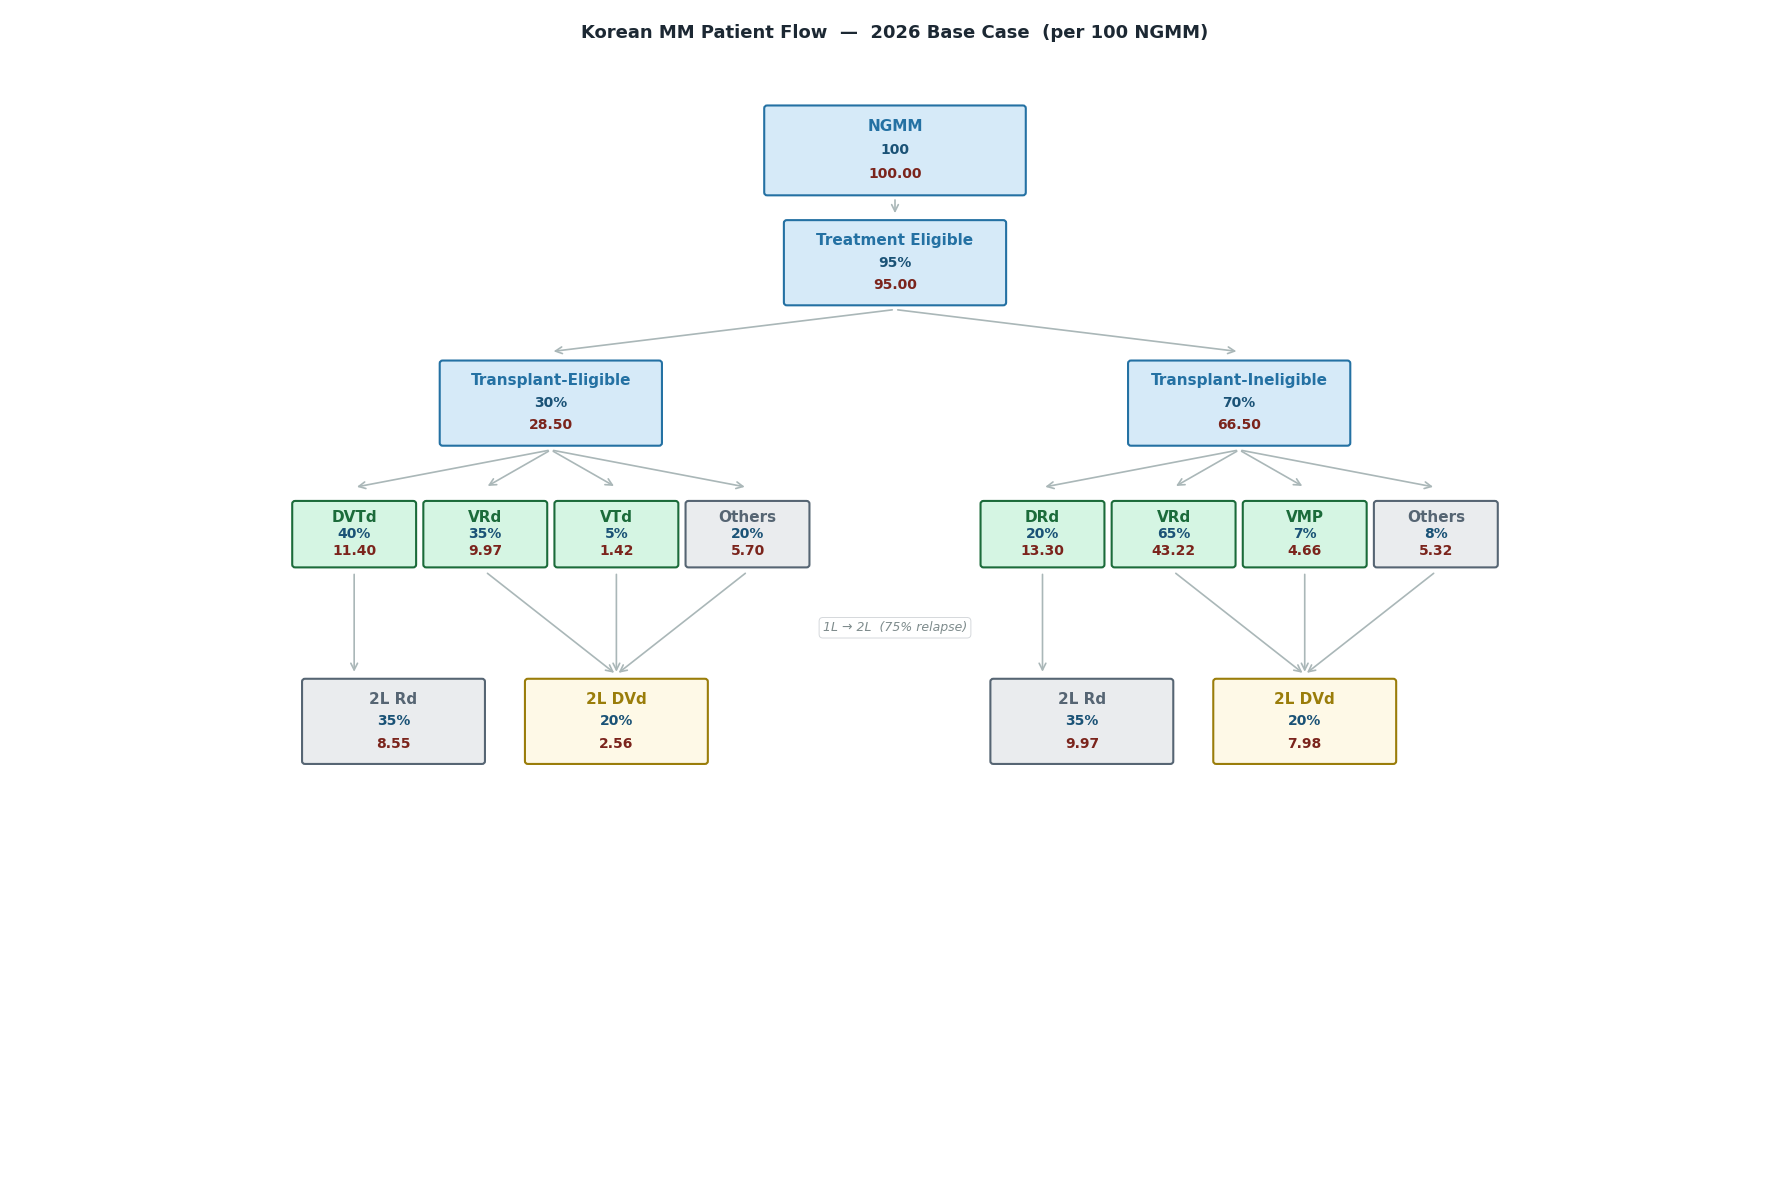

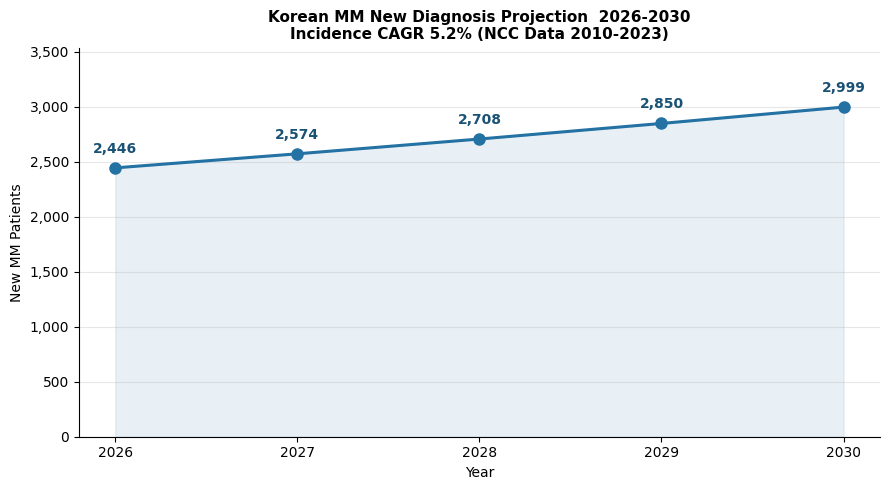

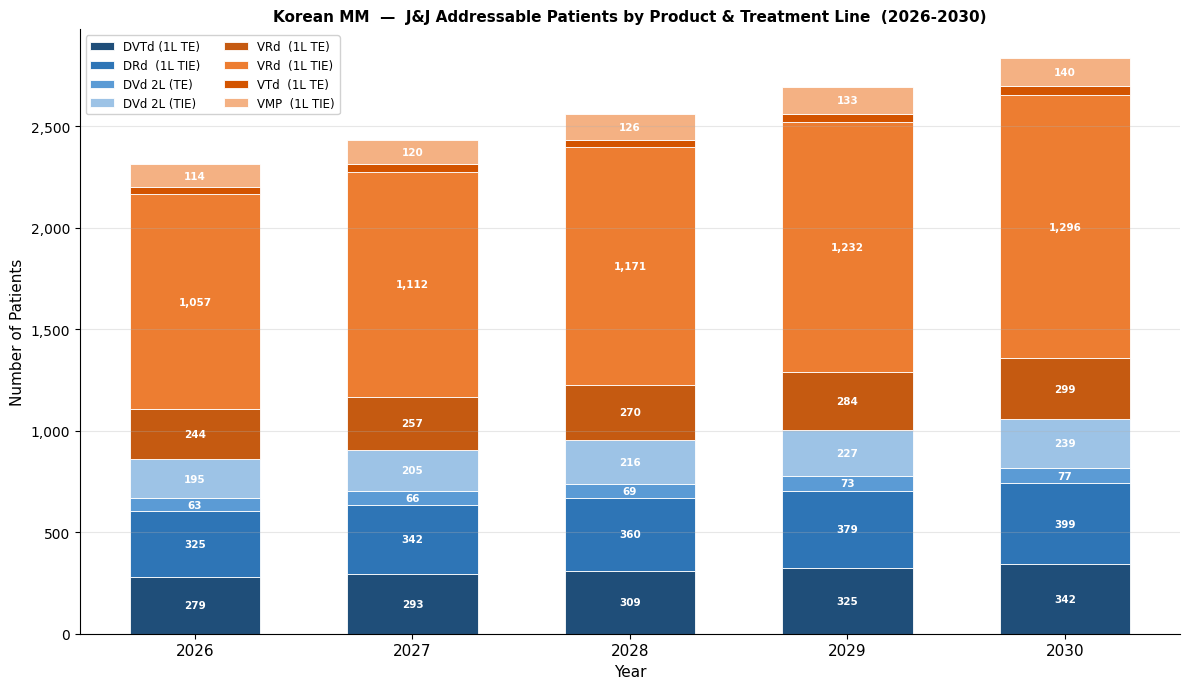

In [71]:
# Patient Flow Model + 2 Charts ─────────────────────────────

# ─── 1. Parameters ────────────────────────────────────────────────────────────
BASE_YEAR      = 2023
BASE_INCIDENCE = inc_2023
ELIGIBLE_RATE  = 0.95
TE_RATE        = 0.30
TIE_RATE       = 0.70

# 1L TE (sums to 100%)
DVTD_TE  = 0.40   # DVTd  -- Dara-exposed
VRD_TE   = 0.35   # VRd   -- Dara-naive
VTD_TE   = 0.05   # VTd   -- Dara-naive
OTH_TE   = 0.20   # Others -- Dara-naive

# 1L TIE (sums to 100%)
DRD_TIE  = 0.20   # DRd    -- Dara-exposed
VRD_TIE  = 0.65   # VRd    -- Dara-naive
VMP_TIE  = 0.07   # VMP    -- Dara-naive
OTH_TIE  = 0.08   # Others -- Dara-naive

# Transition rates and 2L penetration
TRANS_1L_2L  = 0.75
RD_2L_RATE = 0.35     # Dara-exposed 2L
DVd_2L_RATE  = 0.20   # Dara-naive 2L


CAGR_INC       = cagr_inc_full    # 5.2% (NCC 2010-2023)
FORECAST_YEARS = list(range(2026, 2031))

def inc_proj(yr):
    return max(0, BASE_INCIDENCE * (1 + CAGR_INC) ** (yr - BASE_YEAR))

# ─── 2. Patient Flow Calculation ──────────────────────────────────────────────
results = {}
for yr in FORECAST_YEARS:
    ngmm = inc_proj(yr) * ELIGIBLE_RATE
    te   = ngmm * TE_RATE
    tie  = ngmm * TIE_RATE

    n_dvtd    = te  * DVTD_TE
    n_vrd_te  = te  * VRD_TE
    n_vtd     = te  * VTD_TE
    n_oth_te  = te  * OTH_TE
    n_drd     = tie * DRD_TIE
    n_vrd_tie = tie * VRD_TIE
    n_vmp     = tie * VMP_TIE
    n_oth_tie = tie * OTH_TIE

    te_dara_exp    = n_dvtd
    te_dara_naive  = n_vrd_te + n_vtd + n_oth_te
    tie_dara_exp   = n_drd
    tie_dara_naive = n_vrd_tie + n_vmp + n_oth_tie

    te_rd_2l  = te_dara_exp    * TRANS_1L_2L
    te_dvd_2l   = te_dara_naive  * TRANS_1L_2L * DVd_2L_RATE
    tie_rd_2l = tie_dara_exp   * TRANS_1L_2L
    tie_dvd_2l  = tie_dara_naive * TRANS_1L_2L * DVd_2L_RATE



    results[yr] = dict(
        ngmm=ngmm, te=te, tie=tie,
        n_dvtd=n_dvtd, n_vrd_te=n_vrd_te, n_vtd=n_vtd, n_oth_te=n_oth_te,
        n_drd=n_drd, n_vrd_tie=n_vrd_tie, n_vmp=n_vmp, n_oth_tie=n_oth_tie,
        te_dara_exp=te_dara_exp, te_dara_naive=te_dara_naive,
        tie_dara_exp=tie_dara_exp, tie_dara_naive=tie_dara_naive,
        te_rd_2l=te_rd_2l, te_dvd_2l=te_dvd_2l,
        tie_rd_2l=tie_rd_2l, tie_dvd_2l=tie_dvd_2l,
    )

# ─── 3. Summary Table ─────────────────────────────────────────────────────────
print("=" * 75)
print("  Korean MM Patient Flow Model — Patient Counts (2026-2030)")
print("=" * 75)
print(f"\n  {'Segment':<26}", *[f"{y:>9}" for y in FORECAST_YEARS])
print("  " + "-" * 71)

sections = {
    "Patient Pool": [
        ('ngmm',      'NGMM (treatment eligible)'),
        ('te',        'Transplant-Eligible (TE 30%)'),
        ('tie',       'Transplant-Ineligible (TIE 70%)'),
    ],
    "1L TE": [
        ('n_dvtd',    'DVTd  (Dara-exposed, 40%)'),
        ('n_vrd_te',  'VRd   (Dara-naive,   35%)'),
    ],
    "1L TIE": [
        ('n_drd',     'DRd   (Dara-exposed, 20%)'),
        ('n_vrd_tie', 'VRd   (Dara-naive,   65%)'),
        ('n_vmp',     'VMP   (Dara-naive,    7%)'),
    ],
    "2L (DVd -- Dara-naive only)": [
        ('te_dvd_2l',  'DVd TE  (20% of Dara-naive 2L)'),
        ('tie_dvd_2l', 'DVd TIE (20% of Dara-naive 2L)'),
    ]
}

for section, items in sections.items():
    print(f"\n  [{section}]")
    for k, lbl in items:
        print(f"  {lbl:<34}", *[f"{results[y][k]:>9.1f}" for y in FORECAST_YEARS])

print("\n" + "=" * 75)

yr = 2026
r  = results[yr]

nf = 100 / inc_proj(yr)

C_BLUE  = '#2471A3'; BG_BLUE  = '#D6EAF8'
C_GREEN = '#1B6B3A'; BG_GREEN = '#D5F5E3'
C_GRAY  = '#566573'; BG_GRAY  = '#EAECEE'
C_GOLD  = '#9A7D0A'; BG_GOLD  = '#FEF9E7'

te_rd_2l  = r['te_rd_2l']
tie_rd_2l = r['tie_rd_2l']
te_dvd_2l  = r['te_dvd_2l']
tie_dvd_2l = r['tie_dvd_2l']

fig1, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12.5)
ax.axis('off')

# ─── Chart 1: Patient Flow Tree ───────────────────────────────────────────────
YN = 11.0; YE = 9.8; YA = 8.3; Y1 = 6.9; Y2 = 4.9
XC = 9.0

X_TE = 5.5
X_TIE = 12.5

X_TE_COL  = np.linspace(3.5, 7.5, 4)
X_TIE_COL = np.linspace(10.5, 14.5, 4)

X_2L_TE_RD  = X_TE_COL[0]
X_2L_TE_DVD = np.mean(X_TE_COL[1:])
X_2L_TIE_RD  = X_TIE_COL[0]
X_2L_TIE_DVD = np.mean(X_TIE_COL[1:])

BOX_W_TOP = 2.6
BOX_H_TOP = 0.9
BOX_W_1L  = 1.2
BOX_H_1L  = 0.65
BOX_W_2L  = 1.8
BOX_H_2L  = 0.85

# ───────────────── Title ─────────────────
ax.text(XC, 12.2,
        f'Korean MM Patient Flow  —  {yr} Base Case  (per 100 NGMM)',
        ha='center', fontsize=13, fontweight='bold', color='#1C2833')

# ───────────────── Top boxes ─────────────────
box(XC, YN, 'NGMM', '100', 100.0, C_BLUE, BG_BLUE, BOX_W_TOP, BOX_H_TOP)
box(XC, YE, 'Treatment Eligible', '95%', r['ngmm'] * nf,
    C_BLUE, BG_BLUE, BOX_W_TOP-0.4, BOX_H_TOP-0.05)

arr(XC, YN-0.5, XC, YE +0.5)

# ───────────────── Split ─────────────────
arr(XC, YE-0.5, X_TE,  YA+0.55)
arr(XC, YE-0.5, X_TIE, YA+0.55)

box(X_TE,  YA, 'Transplant-Eligible',   '30%', r['te']  * nf,
    C_BLUE, BG_BLUE, BOX_W_TOP-0.4, BOX_H_TOP-0.05)
box(X_TIE, YA, 'Transplant-Ineligible', '70%', r['tie'] * nf,
    C_BLUE, BG_BLUE, BOX_W_TOP-0.4, BOX_H_TOP-0.05)

# ───────────────── 1L ─────────────────
for xc in X_TE_COL:
    arr(X_TE, YA - 0.5 , xc, Y1 + 0.5)
for xc in X_TIE_COL:
    arr(X_TIE, YA - 0.5, xc, Y1 + 0.5)

# ───────────────── 1L boxes ─────────────────
# TE
box(X_TE_COL[0], Y1, 'DVTd', f'{DVTD_TE*100:.0f}%', r['n_dvtd']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TE_COL[1], Y1, 'VRd',  f'{VRD_TE*100:.0f}%', r['n_vrd_te']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TE_COL[2], Y1, 'VTd',  f'{VTD_TE*100:.0f}%', r['n_vtd']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TE_COL[3], Y1, 'Others', f'{OTH_TE*100:.0f}%', r['n_oth_te']*nf, C_GRAY, BG_GRAY, BOX_W_1L, BOX_H_1L)

# TIE
box(X_TIE_COL[0], Y1, 'DRd', f'{DRD_TIE*100:.0f}%', r['n_drd']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TIE_COL[1], Y1, 'VRd', f'{VRD_TIE*100:.0f}%', r['n_vrd_tie']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TIE_COL[2], Y1, 'VMP', f'{VMP_TIE*100:.0f}%', r['n_vmp']*nf, C_GREEN, BG_GREEN, BOX_W_1L, BOX_H_1L)
box(X_TIE_COL[3], Y1, 'Others', f'{OTH_TIE*100:.0f}%', r['n_oth_tie']*nf, C_GRAY, BG_GRAY, BOX_W_1L, BOX_H_1L)

mid_label(XC, (Y1+Y2)/2, '1L → 2L  (75% relapse)')

# ───────────────── 1L → 2L ─────────────────
# TE Rd
arr(X_TE_COL[0], Y1 - 0.4, X_2L_TE_RD, Y2 + 0.5)

# TE DVd
for i, xc in enumerate(X_TE_COL[1:]):
    arr(xc, Y1 - 0.4 , X_2L_TE_DVD, Y2 + 0.5)

# TIE Rd
arr(X_TIE_COL[0], Y1 - 0.4, X_2L_TIE_RD, Y2 + 0.5)

# TIE DVd
for i, xc in enumerate(X_TIE_COL[1:]):
    arr(xc, Y1 - 0.4, X_2L_TIE_DVD, Y2 + 0.5)

# ───────────────── 2L boxes ─────────────────
box(X_2L_TE_RD + 0.4,  Y2, '2L Rd',  f'{RD_2L_RATE*100:.0f}%', te_rd_2l*nf,  C_GRAY, BG_GRAY, BOX_W_2L, BOX_H_2L)
box(X_2L_TE_DVD, Y2, '2L DVd', f'{DVd_2L_RATE*100:.0f}%', te_dvd_2l*nf, C_GOLD, BG_GOLD, BOX_W_2L, BOX_H_2L)

box(X_2L_TIE_RD + 0.4,  Y2, '2L Rd',  f'{RD_2L_RATE*100:.0f}%', tie_rd_2l*nf,  C_GRAY, BG_GRAY, BOX_W_2L, BOX_H_2L)
box(X_2L_TIE_DVD, Y2, '2L DVd', f'{DVd_2L_RATE*100:.0f}%', tie_dvd_2l*nf, C_GOLD, BG_GOLD, BOX_W_2L, BOX_H_2L)

plt.tight_layout()
plt.show()

# ─── Chart 2: NGMM Incidence Line Chart ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
ngmm_proj = [inc_proj(yr) for yr in FORECAST_YEARS]

ax2.plot(FORECAST_YEARS, ngmm_proj, 'o-',
         color=C_BLUE, lw=2.2, ms=8, zorder=3)
ax2.fill_between(FORECAST_YEARS, ngmm_proj, alpha=0.1, color=C_BLUE)

for yr, n in zip(FORECAST_YEARS, ngmm_proj):
    ax2.annotate(f'{n:,.0f}', (yr, n),
                 textcoords='offset points', xytext=(0, 11),
                 ha='center', fontsize=10,
                 color='#1A5276', fontweight='bold')

ax2.set_title(
    f'Korean MM New Diagnosis Projection  2026-2030\n'
    f'Incidence CAGR {CAGR_INC*100:.1f}% (NCC Data 2010-2023)',
    fontsize=11, fontweight='bold')
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('New MM Patients', fontsize=10)
ax2.set_xticks(FORECAST_YEARS)
ax2.set_ylim(0, max(ngmm_proj) * 1.18)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(PATH + 'chart2_incidence.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Chart 3: Stacked Bar — Patients by Product & Line ────────────────────────
fig3, ax3 = plt.subplots(figsize=(12, 7))
x  = np.arange(len(FORECAST_YEARS))
bw = 0.6

stacks = [
    ('DVTd (1L TE)',
     [results[y]['n_dvtd']    for y in FORECAST_YEARS], '#1F4E79'),
    ('DRd  (1L TIE)',
     [results[y]['n_drd']     for y in FORECAST_YEARS], '#2E75B6'),
    ('DVd 2L (TE)',
     [results[y]['te_dvd_2l'] for y in FORECAST_YEARS], '#5B9BD5'),
    ('DVd 2L (TIE)',
     [results[y]['tie_dvd_2l']for y in FORECAST_YEARS], '#9DC3E6'),

    ('VRd  (1L TE)',
     [results[y]['n_vrd_te']  for y in FORECAST_YEARS], '#C55A11'),
    ('VRd  (1L TIE)',
     [results[y]['n_vrd_tie'] for y in FORECAST_YEARS], '#ED7D31'),
    ('VTd  (1L TE)',
     [results[y]['n_vtd']  for y in FORECAST_YEARS], '#D35400'),
    ('VMP  (1L TIE)',
     [results[y]['n_vmp']     for y in FORECAST_YEARS], '#F4B183'),
]

bottom    = np.zeros(len(FORECAST_YEARS))
threshold = max(ngmm_proj) * 0.015

for label, vals, color in stacks:
    v = np.array(vals)
    ax3.bar(x, v, bottom=bottom, label=label,
             color=color, edgecolor='white', lw=0.6, width=bw)
    for i, (val, bot) in enumerate(zip(v, bottom)):
        if val > threshold:
            ax3.text(x[i], bot + val / 2, f'{val:,.0f}',
                     ha='center', va='center', fontsize=7.5,
                     color='white', fontweight='bold')
    bottom += v

ax3.set_xticks(x)
ax3.set_xticklabels(FORECAST_YEARS, fontsize=11)
ax3.set_xlabel('Year', fontsize=11)
ax3.set_ylabel('Number of Patients', fontsize=11)
ax3.set_title(
    'Korean MM  —  J&J Addressable Patients by Product & Treatment Line  (2026-2030)',
    fontsize=11, fontweight='bold')
ax3.legend(loc='upper left', fontsize=8.5, framealpha=0.9, ncol=2)
ax3.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig(PATH + 'chart3_patients_stack.png', dpi=150, bbox_inches='tight')
plt.show()


=== Annual Revenue Summary (KRW mm) ===
      BTZ (KRW mm)  DARA (KRW mm)  Total (KRW mm)  DARA Share (%)
Year                                                             
2026        5704.3        62359.6         68063.9            91.6
2027        6002.6        65620.7         71623.3            91.6
2028        6316.5        69052.3         75368.8            91.6
2029        6646.8        72663.3         79310.1            91.6
2030        6994.4        76463.2         83457.6            91.6


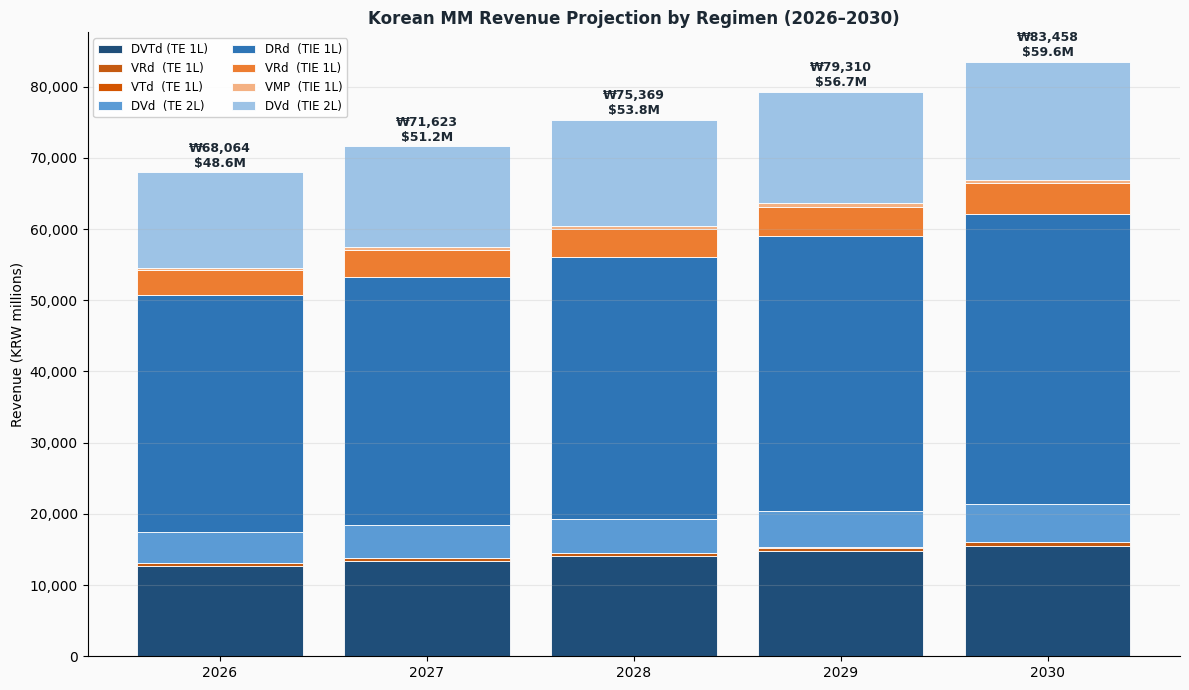

In [72]:
# Revenue Projection  ─────────────────────────────────────

# ── FX Rate ─────────────────────────────────────────────────────────────
FX = 1400  # KRW per USD

# ── Velcade share (Korea) ───────────────────────────────────────────────
VELCADE_SHARE = 0.20

# ── Revenue per patient (KRW) ───────────────────────────────────────────
REV = {
    'DVTd (TE 1L)' : {'btz':  8_313_328 * VELCADE_SHARE, 'dara': 43_764_384},
    'VRd  (TE 1L)' : {'btz':  8_313_328 * VELCADE_SHARE, 'dara': 0},
    'VTd  (TE 1L)' : {'btz':  8_313_328 * VELCADE_SHARE, 'dara': 0},
    'DVd  (TE 2L)' : {'btz': 16_626_656 * VELCADE_SHARE, 'dara': 65_646_576},

    'DRd  (TIE 1L)': {'btz': 0, 'dara': 102_116_896},
    'VRd  (TIE 1L)': {'btz': 16_626_656 * VELCADE_SHARE, 'dara': 0},
    'VMP  (TIE 1L)': {'btz': 17_665_822 * VELCADE_SHARE, 'dara': 0},
    'DVd  (TIE 2L)': {'btz': 16_626_656 * VELCADE_SHARE, 'dara': 65_646_576},
}

# ── Forecast years ───────────────────────────────────────────────────────
YEARS = list(range(2026, 2031))
MM = 1_000_000  # KRW → million

# ── Patients (FIXED: per 100 → actual scaling) ───────────────────────────
def get_patients(yr):
    total = inc_proj(yr)
    scale = total / 100

    return {
        'DVTd (TE 1L)' : 11.40 * scale,
        'VRd  (TE 1L)' : 9.98  * scale,
        'VTd  (TE 1L)' : 1.43  * scale,
        'DVd  (TE 2L)' : 2.57  * scale,

        'DRd  (TIE 1L)': 13.30 * scale,
        'VRd  (TIE 1L)': 43.23 * scale,
        'VMP  (TIE 1L)': 4.66  * scale,
        'DVd  (TIE 2L)': 7.98  * scale,
    }

# ── Build dataframe ──────────────────────────────────────────────────────
records = []

for yr in YEARS:
    pts = get_patients(yr)

    for reg, r in REV.items():
        n = pts[reg]

        records.append({
            'Year': yr,
            'Regimen': reg,
            'Patients': n,
            'BTZ_Rev': n * r['btz'],
            'DARA_Rev': n * r['dara'],
            'Total_Rev': n * (r['btz'] + r['dara']),
        })

df = pd.DataFrame(records)

# ── Summary ──────────────────────────────────────────────────────────────
ann = df.groupby('Year')[['BTZ_Rev','DARA_Rev','Total_Rev']].sum() / MM
ann.columns = ['BTZ (KRW mm)', 'DARA (KRW mm)', 'Total (KRW mm)']
ann['DARA Share (%)'] = (ann['DARA (KRW mm)'] / ann['Total (KRW mm)'] * 100).round(1)

print("\n=== Annual Revenue Summary (KRW mm) ===")
print(ann.round(1))

C = {
    'DVTd (TE 1L)' : '#1F4E79',
    'DRd  (TIE 1L)': '#2E75B6',
    'DVd  (TE 2L)' : '#5B9BD5',
    'DVd  (TIE 2L)': '#9DC3E6',

    'VRd  (TE 1L)' : '#C55A11',
    'VRd  (TIE 1L)': '#ED7D31',
    'VMP  (TIE 1L)': '#F4B183',
    'VTd  (TE 1L)' : '#D35400',

}

REG_ORDER = list(REV.keys())

# ── Chart: Stacked Revenue ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

bottoms = np.zeros(len(YEARS))

for reg in REG_ORDER:
    vals = np.array([
        df[(df.Year == yr) & (df.Regimen == reg)]['Total_Rev'].sum() / MM
        for yr in YEARS
    ])

    ax.bar(YEARS, vals,
           bottom=bottoms,
           label=reg.strip(),
           color=C[reg],
           edgecolor='white',
           linewidth=0.6)

    bottoms += vals

# ── Top labels (KRW + USD) ───────────────────────────────────────────────
for i, total in enumerate(bottoms):
    usd = total / FX  # million USD

    ax.text(YEARS[i], total + total * 0.01,
            f'₩{total:,.0f}\n${usd:,.1f}M',
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='#1C2833')

# ── Styling ──────────────────────────────────────────────────────────────
ax.set_title(
    'Korean MM Revenue Projection by Regimen (2026–2030)',
    fontsize=12,
    fontweight='bold',
    color='#1C2833'
)

ax.set_ylabel('Revenue (KRW millions)', fontsize=10)
ax.set_xticks(YEARS)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
)

ax.legend(loc='upper left', fontsize=8.5, ncol=2, framealpha=0.9)

ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(PATH + 'final_revenue_chart.png', dpi=150, bbox_inches='tight')
plt.show()
